C=0.0010 → Accuracy=0.6709
C=0.0046 → Accuracy=0.7328
C=0.0215 → Accuracy=0.7833
C=0.1000 → Accuracy=0.8177
C=0.4642 → Accuracy=0.8142
C=2.1544 → Accuracy=0.8222
C=10.0000 → Accuracy=0.8096
C=46.4159 → Accuracy=0.8028
C=215.4435 → Accuracy=0.7947
C=1000.0000 → Accuracy=0.7924


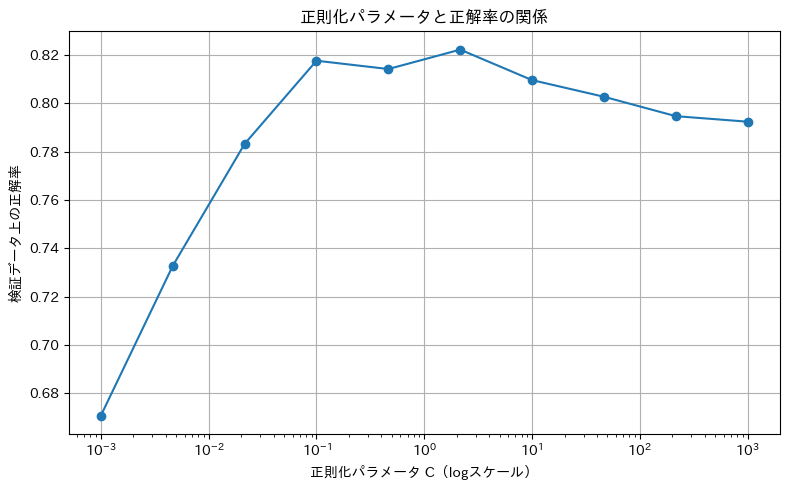

In [4]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import japanize_matplotlib

# --- 学習データの読み込み ---
texts = []
labels = []

with open("train_features.txt", "r", encoding="utf-8") as f:
    for line in f:
        item = ast.literal_eval(line.strip())
        texts.append(item['text'])
        labels.append(int(item['label']))

# --- 検証データの読み込み ---
val_texts = []
val_labels = []

with open("dev_features.txt", "r", encoding="utf-8") as f:
    for line in f:
        item = ast.literal_eval(line.strip())
        val_texts.append(item['text'])
        val_labels.append(int(item['label']))

# --- ベクトル化 ---
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(texts)
y_train = np.array(labels)

X_val = vectorizer.transform(val_texts)
y_val = np.array(val_labels)

# --- 正則化パラメータのリスト（ログスケールで調整） ---
C_values = np.logspace(-3, 3, 10)  # 0.001〜1000

val_accuracies = []

# --- 各Cに対して学習・評価 ---
for C in C_values:
    clf = LogisticRegression(C=C, max_iter=1000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    val_accuracies.append(acc)
    print(f"C={C:.4f} → Accuracy={acc:.4f}")

# --- グラフの描画 ---
plt.figure(figsize=(8, 5))
plt.plot(C_values, val_accuracies, marker='o')
plt.xscale("log")
plt.xlabel("正則化パラメータ C（logスケール）")
plt.ylabel("検証データ上の正解率")
plt.title("正則化パラメータと正解率の関係")
plt.grid(True)
plt.tight_layout()
plt.show()
